In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

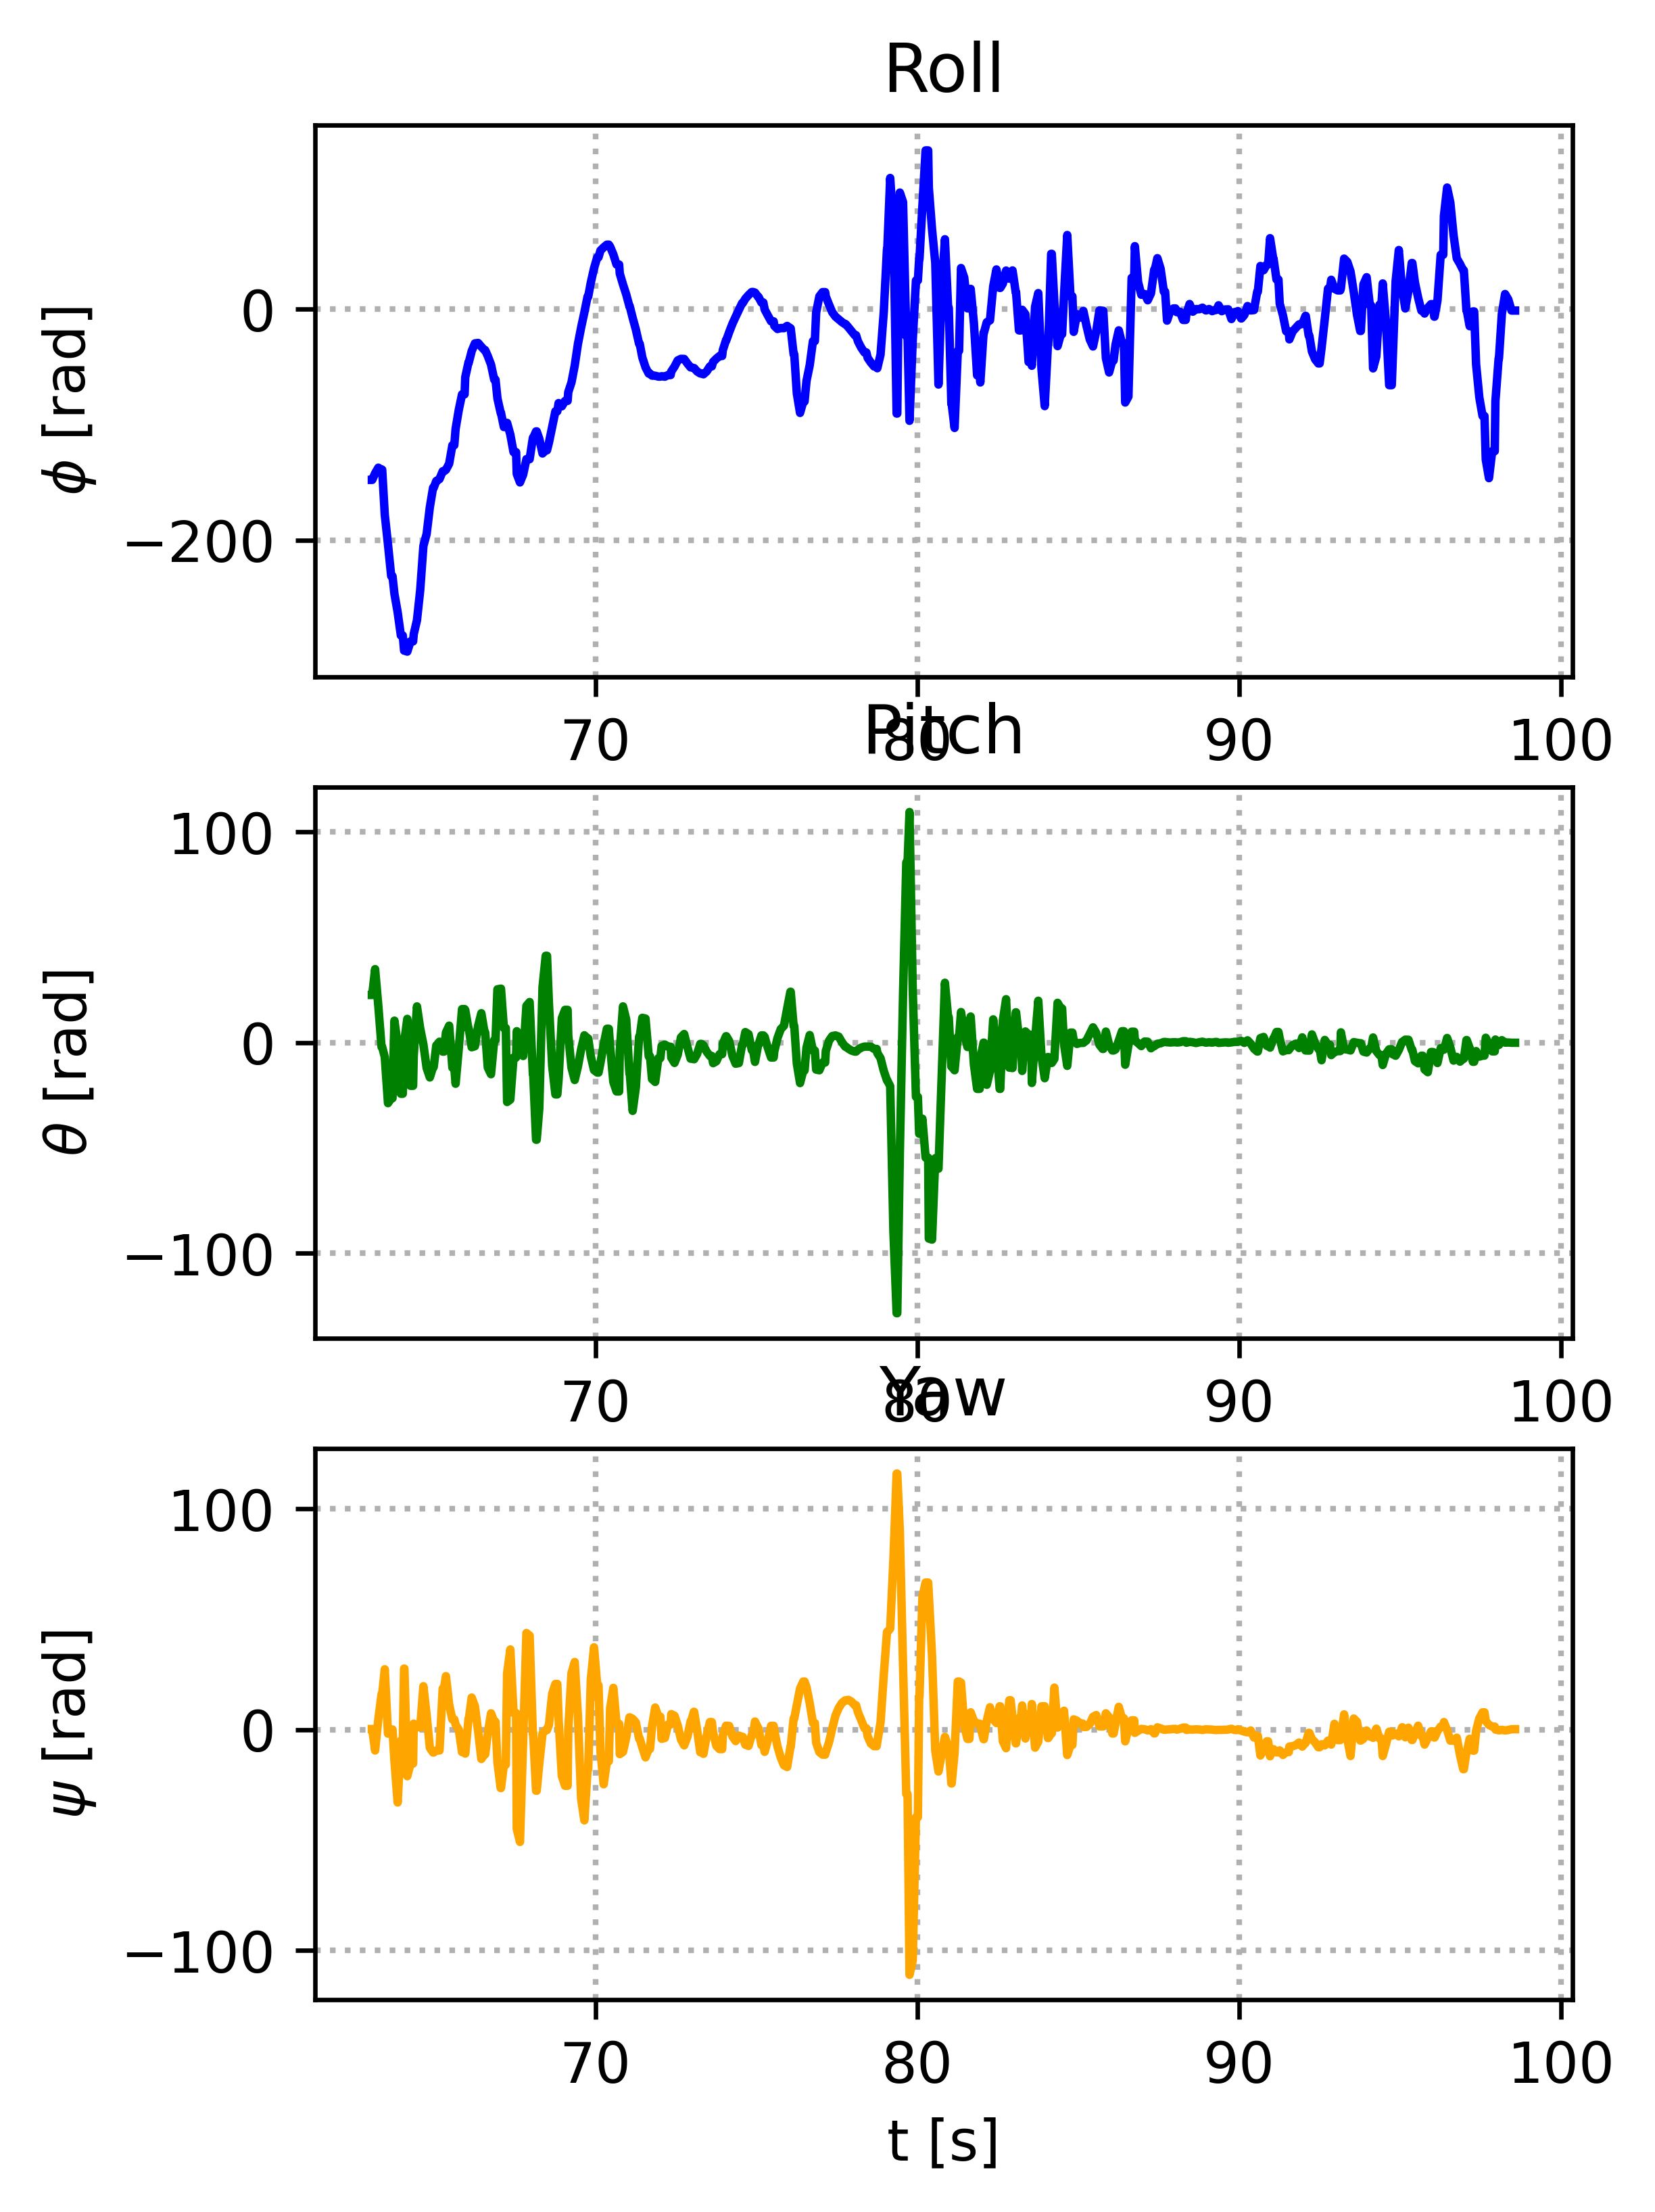

In [23]:
df = pd.read_csv('FT1_primary.csv')

t_old = df.iloc[2450:,4].to_numpy()
roll = df.iloc[2450:,19].to_numpy()
pitch = df.iloc[2450:,20].to_numpy()
yaw = df.iloc[2450:,21].to_numpy()

fig, axs = plt.subplots(3,1,dpi=300,figsize=(4,6))

# roll
axs[0].plot(t_old, roll, c='blue')
axs[0].grid(lw=1, ls=':')
axs[0].set_xlabel('t [s]')
axs[0].set_ylabel(r'$\phi$ [rad]')
axs[0].set_title('Roll')
# pitch
axs[1].plot(t_old, pitch, c='green')
axs[1].grid(lw=1, ls=':')
axs[1].set_xlabel('t [s]')
axs[1].set_ylabel(r'$\theta$ [rad]')
axs[1].set_title('Pitch')
# yaw
axs[2].plot(t_old, yaw, c='orange')
axs[2].grid(lw=1, ls=':')
axs[2].set_xlabel('t [s]')
axs[2].set_ylabel(r'$\psi$ [rad]')
axs[2].set_title('Yaw');

In [24]:
t = np.linspace(t_old[0], t_old[-1], len(t_old))
dt = np.diff(t)[0]
roll = np.interp(t, t_old, roll)

In [30]:
import numpy as np


def wrap_angle_rad(a: float) -> float:
    """Wrap angle to [-pi, pi)."""
    return (a + np.pi) % (2.0 * np.pi) - np.pi


class PIDTorqueController:
    """
    PID controller that outputs a torque command for roll control.

    Notes:
    - Uses e_phi = wrap(phi_cmd - phi)
    - Uses derivative term from measured/estimated omega: d/dt(phi) = omega
      so d/dt(error) ~ phi_cmd_dot - omega
    - Includes basic anti-windup via integrator clamping when saturated.
    """

    def __init__(
        self,
        Kp: float,
        Ki: float,
        Kd: float,
        tau_max: float,
        dt: float,
        integrator_limit: float = np.inf,
    ):
        self.Kp = float(Kp)
        self.Ki = float(Ki)
        self.Kd = float(Kd)
        self.tau_max = float(tau_max)
        self.dt = float(dt)

        self.integrator = 0.0
        self.integrator_limit = float(integrator_limit)

    def reset(self):
        self.integrator = 0.0

    def step(self, phi: float, omega: float, phi_cmd: float, phi_cmd_dot: float = 0.0) -> float:
        """
        Compute saturated torque command.

        Args:
            phi: current roll angle (rad)
            omega: current roll rate (rad/s)
            phi_cmd: commanded roll angle (rad)
            phi_cmd_dot: commanded roll rate (rad/s), default 0

        Returns:
            tau_cmd_sat: saturated torque command (N*m)
        """
        e = wrap_angle_rad(phi_cmd - phi)

        # Derivative of error ~ phi_cmd_dot - omega
        e_dot = phi_cmd_dot - omega

        # Provisional (unsaturated) torque using current integrator
        tau_unsat = self.Kp * e + self.Ki * self.integrator + self.Kd * e_dot

        # Saturate torque
        tau_sat = float(np.clip(tau_unsat, -self.tau_max, self.tau_max))

        # Anti-windup: only integrate if not saturated OR if integration would reduce saturation.
        # If saturated high (tau_unsat > tau_max), only integrate if e is negative (reduces torque).
        # If saturated low (tau_unsat < -tau_max), only integrate if e is positive.
        saturated_high = tau_unsat > self.tau_max
        saturated_low = tau_unsat < -self.tau_max

        allow_integrate = True
        if saturated_high and e > 0:
            allow_integrate = False
        if saturated_low and e < 0:
            allow_integrate = False

        if allow_integrate and self.Ki != 0.0:
            self.integrator += self.dt * e
            # Clamp integrator to avoid runaway
            if np.isfinite(self.integrator_limit):
                self.integrator = float(np.clip(self.integrator, -self.integrator_limit, self.integrator_limit))

        # Recompute with updated integrator (optional but a bit cleaner)
        tau_unsat2 = self.Kp * e + self.Ki * self.integrator + self.Kd * e_dot
        tau_sat2 = float(np.clip(tau_unsat2, -self.tau_max, self.tau_max))

        return tau_sat2


class FirstOrderActuator:
    """
    Simple actuator torque dynamics:
    - optional deadband
    - saturation (already applied by controller typically)
    - first-order lag with time constant T_a
    - optional slew-rate limit
    - optional sample delay (integer number of steps)
    """

    def __init__(
        self,
        dt: float,
        T_a: float = 0.05,
        tau_deadband: float = 0.0,
        tau_slew_rate_max: float | None = None,  # N*m/s, None disables
        delay_steps: int = 0,
        tau_max: float | None = None,  # optional extra safety saturation
    ):
        self.dt = float(dt)
        self.T_a = float(T_a)
        if self.T_a <= 0:
            raise ValueError("T_a must be > 0")

        self.tau_deadband = float(tau_deadband)
        self.tau_slew_rate_max = None if tau_slew_rate_max is None else float(tau_slew_rate_max)
        self.delay_steps = int(delay_steps)
        self.tau_max = None if tau_max is None else float(tau_max)

        self.tau = 0.0  # actual torque output
        self._cmd_buffer = [0.0] * max(0, self.delay_steps)

    def reset(self):
        self.tau = 0.0
        self._cmd_buffer = [0.0] * max(0, self.delay_steps)

    def step(self, tau_cmd: float) -> float:
        """Advance actuator by one time step and return actual torque output."""
        u = float(tau_cmd)

        # Optional extra safety saturation
        if self.tau_max is not None:
            u = float(np.clip(u, -self.tau_max, self.tau_max))

        # Deadband
        if abs(u) < self.tau_deadband:
            u = 0.0

        # Delay
        if self.delay_steps > 0:
            self._cmd_buffer.append(u)
            u = self._cmd_buffer.pop(0)

        # First-order lag: tau_dot = (u - tau)/T_a
        tau_next = self.tau + (self.dt / self.T_a) * (u - self.tau)

        # Slew-rate limit on the *actual torque*
        if self.tau_slew_rate_max is not None:
            max_delta = self.tau_slew_rate_max * self.dt
            delta = float(np.clip(tau_next - self.tau, -max_delta, max_delta))
            tau_next = self.tau + delta

        self.tau = float(tau_next)
        return self.tau


def simulate_control_torques(
    t: np.ndarray,
    phi_truth: np.ndarray,
    omega_truth: np.ndarray,
    phi_cmd_fn,
    controller: PIDTorqueController,
    actuator: FirstOrderActuator,
):
    """
    Simulate commanded + actual control torque time series, given truth phi/omega.
    This isolates the control torque subsystem (useful for debugging).

    Args:
        t: time array (s), shape (N,)
        phi_truth: roll angle truth (rad), shape (N,)
        omega_truth: roll rate truth (rad/s), shape (N,)
        phi_cmd_fn: function phi_cmd_fn(t)->(phi_cmd, phi_cmd_dot)
        controller: PIDTorqueController
        actuator: FirstOrderActuator

    Returns:
        tau_cmd: controller saturated torque command (N*m)
        tau_act: actuator actual torque output (N*m)
        phi_cmd: commanded roll angle (rad)
    """
    N = len(t)
    tau_cmd = np.zeros(N)
    tau_act = np.zeros(N)
    phi_cmd = np.zeros(N)

    controller.reset()
    actuator.reset()

    for k in range(N):
        pc, pc_dot = phi_cmd_fn(t[k])
        phi_cmd[k] = pc

        tau_cmd[k] = controller.step(
            phi=float(phi_truth[k]),
            omega=float(omega_truth[k]),
            phi_cmd=float(pc),
            phi_cmd_dot=float(pc_dot),
        )
        tau_act[k] = actuator.step(float(tau_cmd[k]))

    return tau_cmd, tau_act, phi_cmd


# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":
    dt = 0.01
    T = 10.0
    t = np.arange(0.0, T + dt, dt)
    N = len(t)

    # Fake "truth" signals just for demonstrating torque simulation
    # (In your full sim, phi_truth and omega_truth come from integrating rigid-body dynamics.)
    phi_truth = 0.2 * np.sin(2.0 * np.pi * 0.5 * t)  # rad
    omega_truth = np.gradient(phi_truth, dt)         # rad/s (only for this demo)

    # Command: hold 0, then step to 10 deg at t=2s, then back to 0 at t=7s
    def phi_cmd_fn(tt):
        if tt < 2.0:
            return 0.0, 0.0
        elif tt < 7.0:
            return np.deg2rad(10.0), 0.0
        else:
            return 0.0, 0.0

    # Controller + actuator parameters (placeholder values)
    controller = PIDTorqueController(
        Kp=2.0,                 # N*m/rad
        Ki=0.5,                 # N*m/(rad*s)
        Kd=0.2,                 # N*m/(rad/s)
        tau_max=5.0,            # N*m
        dt=dt,
        integrator_limit=2.0,   # rad*s (keeps integrator bounded)
    )

    actuator = FirstOrderActuator(
        dt=dt,
        T_a=0.05,               # s (actuator lag)
        tau_deadband=0.02,      # N*m
        tau_slew_rate_max=100.0,  # N*m/s
        delay_steps=2,          # 2*dt delay
        tau_max=5.0,            # N*m
    )

    tau_cmd, tau_act, phi_cmd = simulate_control_torques(
        t=t,
        phi_truth=phi_truth,
        omega_truth=omega_truth,
        phi_cmd_fn=phi_cmd_fn,
        controller=controller,
        actuator=actuator,
    )

    # tau_cmd and tau_act are your simulated control torques.
    # You can now plug tau_act into your truth dynamics: omega_dot = (tau_act + tau_dist)/I
    print("Sim complete:")
    print(f"tau_cmd range: [{tau_cmd.min():.3f}, {tau_cmd.max():.3f}] N*m")
    print(f"tau_act range: [{tau_act.min():.3f}, {tau_act.max():.3f}] N*m")


Sim complete:
tau_cmd range: [-0.443, 1.029] N*m
tau_act range: [-0.439, 1.025] N*m


In [31]:
phi_truth

array([ 0.00000000e+00,  6.28215182e-03,  1.25581039e-02, ...,
       -1.25581039e-02, -6.28215182e-03, -2.44929360e-16])

### Simulate

In [32]:
def wrap_angle_rad(a: float) -> float:
    """Wrap angle to [-pi, pi)."""
    return (a + np.pi) % (2.0 * np.pi) - np.pi


class PIDTorqueController:
    """
    PID controller that outputs a (saturated) torque command for roll control.

    e = wrap(phi_cmd - phi)
    e_dot ≈ phi_cmd_dot - omega
    tau_cmd = Kp*e + Ki*∫e dt + Kd*e_dot
    """

    def __init__(
        self,
        Kp: float,
        Ki: float,
        Kd: float,
        tau_max: float,
        dt: float,
        integrator_limit: float = np.inf,
    ):
        self.Kp = float(Kp)
        self.Ki = float(Ki)
        self.Kd = float(Kd)
        self.tau_max = float(tau_max)
        self.dt = float(dt)
        self.integrator_limit = float(integrator_limit)
        self.integrator = 0.0

    def reset(self):
        self.integrator = 0.0

    def step(self, phi: float, omega: float, phi_cmd: float, phi_cmd_dot: float = 0.0) -> float:
        e = wrap_angle_rad(phi_cmd - phi)
        e_dot = phi_cmd_dot - omega

        # Provisional torque (with current integrator)
        tau_unsat = self.Kp * e + self.Ki * self.integrator + self.Kd * e_dot
        tau_sat = float(np.clip(tau_unsat, -self.tau_max, self.tau_max))

        # Anti-windup: only integrate if not saturating in the same direction as the error
        saturated_high = tau_unsat > self.tau_max
        saturated_low = tau_unsat < -self.tau_max

        allow_integrate = True
        if saturated_high and e > 0:
            allow_integrate = False
        if saturated_low and e < 0:
            allow_integrate = False

        if allow_integrate and self.Ki != 0.0:
            self.integrator += self.dt * e
            if np.isfinite(self.integrator_limit):
                self.integrator = float(np.clip(self.integrator, -self.integrator_limit, self.integrator_limit))

        # Recompute after integrator update
        tau_unsat2 = self.Kp * e + self.Ki * self.integrator + self.Kd * e_dot
        tau_sat2 = float(np.clip(tau_unsat2, -self.tau_max, self.tau_max))
        return tau_sat2


class FirstOrderActuator:
    """
    Actuator torque dynamics:
      - optional deadband
      - optional command delay (N samples)
      - first-order lag with time constant T_a
      - optional slew-rate limit on actual torque
      - optional extra saturation
    """

    def __init__(
        self,
        dt: float,
        T_a: float = 0.05,
        tau_deadband: float = 0.0,
        tau_slew_rate_max: float | None = None,  # N*m/s
        delay_steps: int = 0,
        tau_max: float | None = None,
    ):
        self.dt = float(dt)
        self.T_a = float(T_a)
        if self.T_a <= 0:
            raise ValueError("T_a must be > 0")
        self.tau_deadband = float(tau_deadband)
        self.tau_slew_rate_max = None if tau_slew_rate_max is None else float(tau_slew_rate_max)
        self.delay_steps = int(delay_steps)
        self.tau_max = None if tau_max is None else float(tau_max)

        self.tau = 0.0
        self._cmd_buffer = [0.0] * max(0, self.delay_steps)

    def reset(self):
        self.tau = 0.0
        self._cmd_buffer = [0.0] * max(0, self.delay_steps)

    def step(self, tau_cmd: float) -> float:
        u = float(tau_cmd)

        if self.tau_max is not None:
            u = float(np.clip(u, -self.tau_max, self.tau_max))

        if abs(u) < self.tau_deadband:
            u = 0.0

        if self.delay_steps > 0:
            self._cmd_buffer.append(u)
            u = self._cmd_buffer.pop(0)

        # First-order lag
        tau_next = self.tau + (self.dt / self.T_a) * (u - self.tau)

        # Slew-rate limit
        if self.tau_slew_rate_max is not None:
            max_delta = self.tau_slew_rate_max * self.dt
            delta = float(np.clip(tau_next - self.tau, -max_delta, max_delta))
            tau_next = self.tau + delta

        self.tau = float(tau_next)
        return self.tau


class OUProcess:
    """
    Ornstein-Uhlenbeck (Gauss–Markov) colored noise process for disturbance torque:

        tau_{k+1} = a * tau_k + sigma * sqrt(1 - a^2) * N(0,1)
        a = exp(-dt / tau_corr)

    sigma here is the *stationary RMS* of the process (units N*m).
    """

    def __init__(self, dt: float, tau_corr: float, sigma: float, seed: int | None = None, x0: float = 0.0):
        self.dt = float(dt)
        self.tau_corr = float(tau_corr)
        if self.tau_corr <= 0:
            raise ValueError("tau_corr must be > 0")
        self.sigma = float(sigma)
        self.rng = np.random.default_rng(seed)
        self.x = float(x0)

        self.a = float(np.exp(-self.dt / self.tau_corr))
        self.b = float(self.sigma * np.sqrt(1.0 - self.a * self.a))

    def reset(self, x0: float = 0.0):
        self.x = float(x0)

    def step(self) -> float:
        self.x = self.a * self.x + self.b * float(self.rng.standard_normal())
        return self.x


def simulate_truth_roll(
    T: float,
    dt: float,
    I_roll: float,
    phi0: float,
    omega0: float,
    phi_cmd_fn,
    controller: PIDTorqueController,
    actuator: FirstOrderActuator,
    dist_fast: OUProcess | None = None,
    dist_slow: OUProcess | None = None,
    events_fn=None,
):
    """
    Full truth simulation for roll angle phi(t) and roll rate omega(t):

        I * omega_dot = tau_control + tau_disturbance
        phi_dot = omega

    Uses semi-implicit Euler:
        omega_{k+1} = omega_k + dt * (tau_total / I)
        phi_{k+1} = wrap(phi_k + dt * omega_{k+1})

    Args:
        T: total simulation time (s)
        dt: timestep (s)
        I_roll: roll moment of inertia (kg*m^2)
        phi0, omega0: initial conditions (rad, rad/s)
        phi_cmd_fn: function (t)->(phi_cmd, phi_cmd_dot)
        controller: PIDTorqueController
        actuator: FirstOrderActuator
        dist_fast, dist_slow: OUProcess objects for colored disturbance torque (N*m)
        events_fn: optional function (t)->tau_event (N*m) (pulses/steps/bursts)

    Returns:
        dict with time histories: t, phi, omega, tau_cmd, tau_act, tau_dist, tau_total, phi_cmd
    """
    if I_roll <= 0:
        raise ValueError("I_roll must be > 0")
    N = int(np.floor(T / dt)) + 1
    t = np.linspace(0.0, dt * (N - 1), N)

    phi = np.zeros(N)
    omega = np.zeros(N)
    phi_cmd = np.zeros(N)

    tau_cmd = np.zeros(N)
    tau_act = np.zeros(N)
    tau_dist = np.zeros(N)
    tau_total = np.zeros(N)

    # Reset control elements
    controller.reset()
    actuator.reset()
    if dist_fast is not None:
        dist_fast.reset(0.0)
    if dist_slow is not None:
        dist_slow.reset(0.0)

    phi[0] = float(phi0)
    omega[0] = float(omega0)

    for k in range(N - 1):
        tk = t[k]

        # Command
        pc, pc_dot = phi_cmd_fn(tk)
        phi_cmd[k] = pc

        # Controller uses truth (in real life you'd use estimated state here)
        tau_cmd[k] = controller.step(phi=phi[k], omega=omega[k], phi_cmd=pc, phi_cmd_dot=pc_dot)

        # Actuator dynamics
        tau_act[k] = actuator.step(tau_cmd[k])

        # Disturbances
        d = 0.0
        if dist_fast is not None:
            d += dist_fast.step()
        if dist_slow is not None:
            d += dist_slow.step()
        if events_fn is not None:
            d += float(events_fn(tk))
        tau_dist[k] = d

        # Total torque
        tau_total[k] = tau_act[k] + tau_dist[k]

        # Truth dynamics update (semi-implicit)
        omega[k + 1] = omega[k] + dt * (tau_total[k] / I_roll)
        phi[k + 1] = wrap_angle_rad(phi[k] + dt * omega[k + 1])

    # fill last sample command arrays
    pc, _ = phi_cmd_fn(t[-1])
    phi_cmd[-1] = pc
    tau_cmd[-1] = tau_cmd[-2]
    tau_act[-1] = tau_act[-2]
    tau_dist[-1] = tau_dist[-2]
    tau_total[-1] = tau_total[-2]

    return {
        "t": t,
        "phi": phi,
        "omega": omega,
        "phi_cmd": phi_cmd,
        "tau_cmd": tau_cmd,
        "tau_act": tau_act,
        "tau_dist": tau_dist,
        "tau_total": tau_total,
    }


# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":
    dt = 0.01
    T = 12.0

    # Rough roll inertia (kg*m^2) — you should replace with your estimate
    I_roll = 2.0

    # Controller/actuator (placeholder values)
    controller = PIDTorqueController(Kp=4.0, Ki=0.2, Kd=1.2, tau_max=8.0, dt=dt, integrator_limit=3.0)
    actuator = FirstOrderActuator(dt=dt, T_a=0.06, tau_deadband=0.05, tau_slew_rate_max=150.0, delay_steps=2, tau_max=8.0)

    # Disturbance torques: fast buffet + slow bias-like drift
    dist_fast = OUProcess(dt=dt, tau_corr=0.15, sigma=1.5, seed=1)  # N*m RMS
    dist_slow = OUProcess(dt=dt, tau_corr=3.0, sigma=0.4, seed=2)   # N*m RMS

    # Command profile (hold 0, then step to +8 deg, then back)
    def phi_cmd_fn(tt):
        if tt < 2.0:
            return 0.0, 0.0
        elif tt < 8.0:
            return np.deg2rad(8.0), 0.0
        else:
            return 0.0, 0.0

    # Optional disturbance "event": a short pulse at 5s
    def events_fn(tt):
        t0 = 5.0
        A = 4.0         # N*m peak
        s = 0.08        # seconds (pulse width)
        return A * np.exp(-0.5 * ((tt - t0) / s) ** 2)

    out = simulate_truth_roll(
        T=T,
        dt=dt,
        I_roll=I_roll,
        phi0=np.deg2rad(0.0),
        omega0=0.0,
        phi_cmd_fn=phi_cmd_fn,
        controller=controller,
        actuator=actuator,
        dist_fast=dist_fast,
        dist_slow=dist_slow,
        events_fn=events_fn,
    )

    # Truth signals you asked for:
    t = out["t"]
    phi = out["phi"]
    omega = out["omega"]

    print("Truth sim complete.")
    print(f"phi range: [{phi.min():.3f}, {phi.max():.3f}] rad")
    print(f"omega range: [{omega.min():.3f}, {omega.max():.3f}] rad/s")
    print(f"tau_total range: [{out['tau_total'].min():.3f}, {out['tau_total'].max():.3f}] N*m")


Truth sim complete.
phi range: [-1.019, 0.870] rad
omega range: [-1.346, 1.539] rad/s
tau_total range: [-7.648, 6.413] N*m


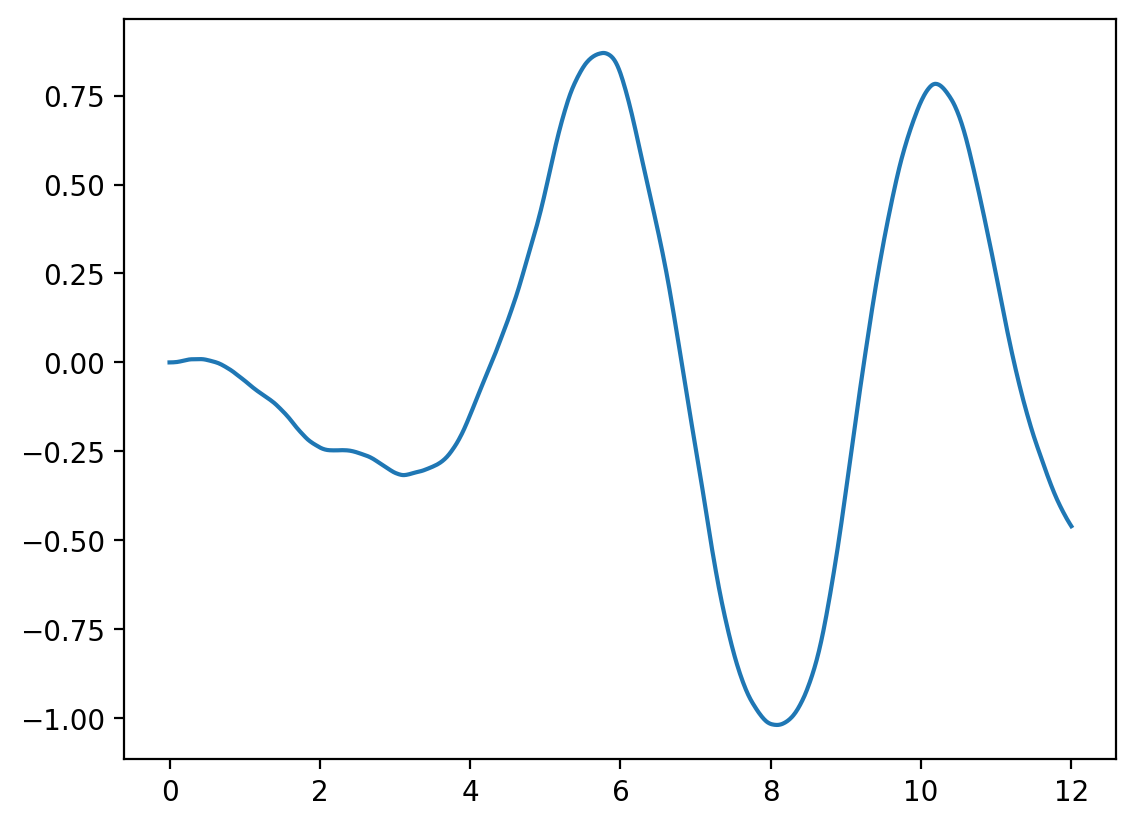

In [ ]:
plt.plot(t, phi)

In [26]:
import scipy.signal as dsp

Nsamples = 2000
fs = 100

time = np.arange(Nsamples) / fs

rng = np.random.default_rng(3)
gaussianNoise = rng.standard_normal(size=time.shape)

whiteGaussianNoise = (gaussianNoise - np.mean(gaussianNoise)) / np.std(gaussianNoise)
# print('\n\n\nWGN MEAN: ', np.mean(wgn))
# print('WGN STD: ', np.std(wgn))

beta = 0.01
sigma = 0.1
b = np.array([np.sqrt(2 * beta * sigma**2)])
a = np.array([1, beta])

gaussMarkovNoise = dsp.lfilter(b, a, whiteGaussianNoise)

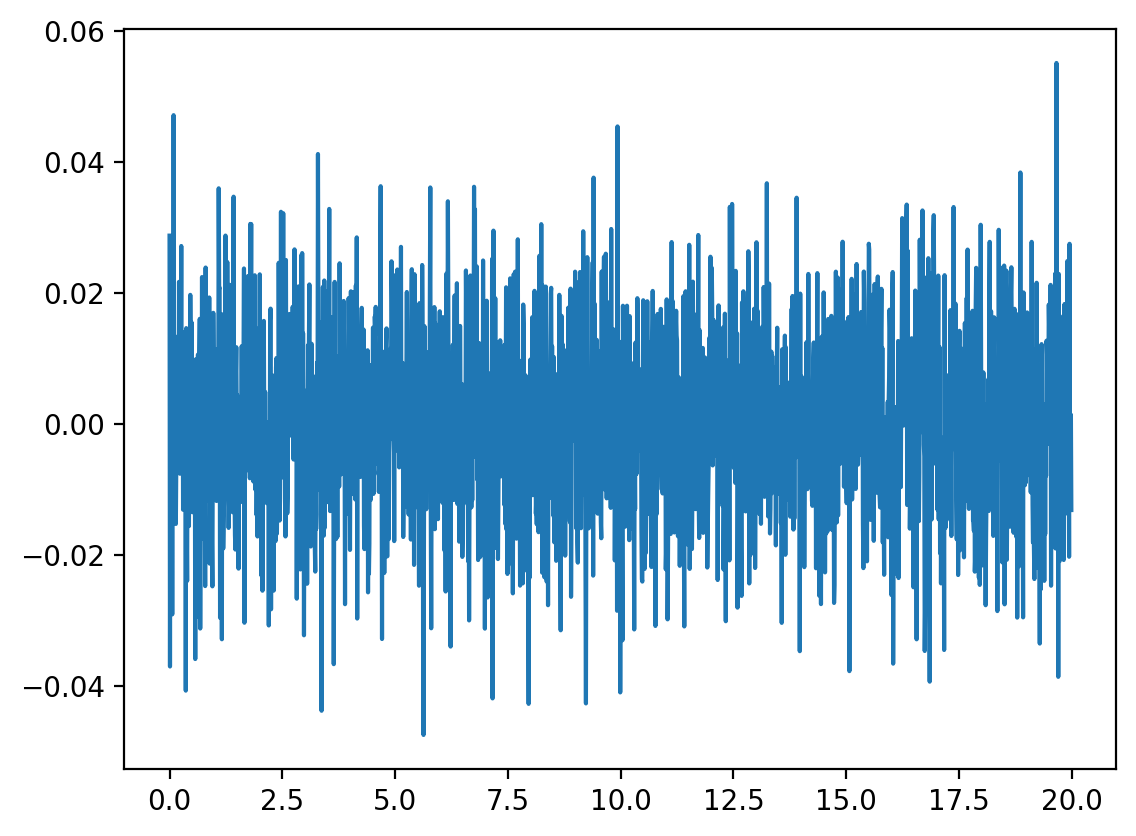

In [29]:
plt.plot(time, gaussMarkovNoise)

In [ ]:
dsp.lfilter()